In [180]:
import pandas as pd
import torch
import os
import re
base = "/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run2Full_allneurons/Expls"
cluster='Cluster3'
for iteration in os.listdir(base):
    explanation_file = f"{cluster}IOUS1024N.csv"
    explanation_file = os.path.join(base,iteration, explanation_file)
    explanations = pd.read_csv(explanation_file)
    formulas = explanations.best_name
    units = explanations.unit
    NOTs_pre_only, NOT_hyp_only, NOT_both, NOT_none = find_notpre_matches(units,formulas)
    break

In [152]:
len(NOTs_pre_only) + len(NOT_hyp_only) + len(NOT_both) + len(NOT_none) #others are where they have (hyp and NOT hyp) or (pre and NOT pre)

785

In [179]:
def count_NOT_pre_concepts(concepts):
    count = 0
    for c in concepts:
        if 'NOT ' in c and 'pre:' in c or "oth:" in c:
            count += 1
    return count

def count_hyp_concepts(concepts):
    count = 0
    for c in concepts:
        if 'NOT ' not in c and 'hyp:' in c or "oth:" in c:
            count += 1
    return count
            

def count_not_hyp_concepts(concepts):
    count = 0
    for c in concepts:
        if 'NOT ' in c and 'hyp:' in c or "oth:" in c:
            count += 1
    return count
 

def count_pre_concepts(concepts):
    count = 0
    for c in concepts:
        if 'NOT ' not in c and 'pre:' in c or "oth:" in c:
            count += 1
    return count
            
    
def find_notpre_matches(units,formulas):
    NOTs_pre_only = []
    NOT_hyp_only = []
    NOT_both = []
    NOT_none = []
    for unit,formula in zip(units,formulas):
        concepts=[]
        concps = re.findall(r'\b(?:NOT )?(?:pre:tok:|pre:tag:|hyp:tag:|hyp:tok:|oth:)\S*', formula)
        for c in concps:
            try:
                end_idx =c.index(')')
            except:
                end_idx = len(c)
            concept = c[:end_idx]
        
            concepts.append(concept)
    
             
        count_NOT_pre = count_NOT_pre_concepts(concepts)
        count_hyp = count_hyp_concepts(concepts)
        count_not_hyp = count_not_hyp_concepts(concepts)
        count_pre = count_pre_concepts(concepts)

        #contradictin: all nots for premise and no nots in hyp or all nots for hyp and no nots premise
        #neutral: 
        #entailemtns: not nots for both

        #nots assoc with premise only
        if count_not_hyp == 0 and count_pre == 0:
            NOTs_pre_only.append(unit)

        # nots assoc with hyp only
        elif count_NOT_pre == 0 and count_hyp == 0:
            NOT_hyp_only.append(unit)

        #nots assoc with both
        elif count_NOT_pre > 0 and count_not_hyp >0 :
            NOT_both.append(unit)

        #no nots
        elif count_NOT_pre == 0 and count_not_hyp == 0:
            NOT_none.append(unit)
      
    
        #get the activations CCE_NLI/BERT/activations/lottery_ticket/Run2Full_allneurons/0_Pruning_Iter/final_layer_activations.pkl and weights for 1024->3 
        
  
    return  NOTs_pre_only, NOT_hyp_only, NOT_both, NOT_none

In [56]:
model_weights =torch.load("/workspace/CCE_NLI/BERT/models/lottery_ticket/Run2Full_allneurons/0_Pruning_Iter/model_best.pth")['state_dict']

In [155]:
weigths=model_weights['mlp.3.weight'].t()
import pickle
import collections
# Replace 'your_file.pkl' with your actual filename

final_layer_activs = "/workspace/CCE_NLI/BERT/activations/lottery_ticket/Run2Full_allneurons/0_Pruning_Iter/final_layer_activations.pkl"
with open(final_layer_activs, 'rb') as f:
    data = pickle.load(f)
    

torch.matmul(torch.from_numpy(data[1][neurons]).unsqueeze(0).cpu(), weigths[neurons].cpu())

tensor([[ 1.2189, -0.4382, -1.6002]])

In [174]:
def contains(neuron):
    return neuron in NOTs_pre_only, neuron in NOT_hyp_only, neuron in  NOT_both, neuron in NOT_none
contains(110)

(False, False, True, False)

In [199]:
#len 10000 1 for each sample each of 1024 for each neuron so its the activation at the 1 of the 1024 neurons for each of the 10000 samples
import torch.nn as nn
def multiply_activs_and_weights(sample_num, rule):
    return torch.matmul(torch.from_numpy(data[sample_num][rule]),weigths[rule].cpu())

nots_hyp_pre_only=[]
for n in NOTs_pre_only:
    nots_hyp_pre_only.append(n)
for n in NOT_hyp_only:
    nots_hyp_pre_only.append(n)
    
#trying to see if neurons that are 
sample_num=199 #classified as neutral and nots being associared without pattern gave highest w*a
sample_num=60 #classiied as contradiction no pattern gave hgihest w*a

#take all predicted contradiction samples. hyp is neurons explainaing nots i
print(f"Label is {val_dataset.labels[sample_num]}")
print(f"Nots only assoc with pre or hyp: output is {multiply_activs_and_weights(sample_num, nots_hyp_pre_only)}")
print(f"Nots assoc with both: output is {multiply_activs_and_weights(sample_num, NOT_both)}")
print(f"No NOTs: output is {multiply_activs_and_weights(sample_num, NOT_none)}")

Label is 2
Nots only assoc with pre or hyp: output is tensor([-1.1479, -1.1363,  1.2207])
Nots assoc with both: output is tensor([-3.2939, -0.0798,  1.6422])
No NOTs: output is tensor([-0.1980, -0.0976, -0.0527])


In [192]:

combo_nots=[]
for n in NOT_both:
    combo_nots.append(n)
for n in NOT_none:
    combo_nots.append(n)

In [93]:
import sys
sys.path.append("/workspace/CCE_NLI/code")
import data
val_dataset = torch.load("/workspace/CCE_NLI/DataLoaders/val_dataset.pth")

In [119]:
weigths[neurons].shape
torch.from_numpy(data[1][neurons]).unsqueeze(0).shape

torch.Size([1, 340])

In [176]:
val_dataset.labels[19]

2

In [74]:

    

pred= collections.defaultdict(int)
for neuron in neurons:
    pred[torch.argmax(weigths[neuron]).detach().cpu().item()] += 1
for k,v in pred.items():
    pred[k] = v/len(neurons)

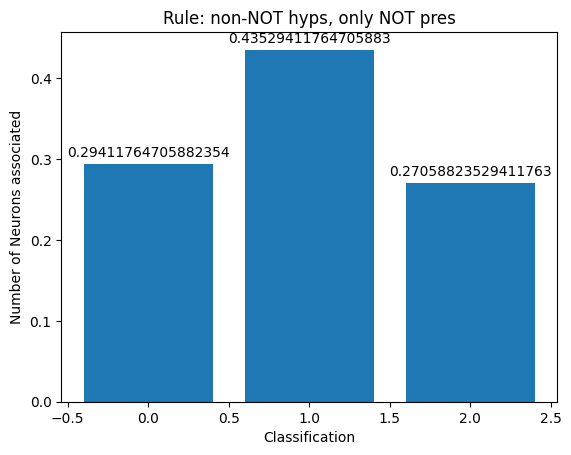

In [75]:
LABEL_STOI = {"entailment": 0, "neutral": 1, "contradiction": 2}

import matplotlib.pyplot as plt

x = [0, 1, 2] 
y = list(pred.values())
plt.bar(x, y)

for x_, y_ in zip(x, y):
    plt.text(x_, y_ + 0.005, str(y_), ha='center', va='bottom')
    
plt.xlabel('Classification')
plt.ylabel('Number of Neurons associated')
plt.title('Rule: non-NOT hyps, only NOT pres')
plt.show()

